# 0. GIỚI THIỆU
## Nội dung

- Import thư viện
- Cấu hình đường dẫn
- Cấu hình biểu đồ

In [184]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [185]:
# Tạo đường dẫn tương đối
CURRENT_DIR = Path.cwd()
BASE_DIR = CURRENT_DIR.parent

DATA_RAW = BASE_DIR / "data" / "raw" / "diabetic_data.csv"
DATA_PROCESSED = BASE_DIR / "data" / "processed" / "diabetic_cleaned_data.csv"

FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [186]:
# Cấu hình chung cho biểu đồ
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# 1. DATA CLEANING
## Mục tiêu

Tiền xử lý dữ liệu bệnh nhân tiểu đường nhằm loại bỏ dữ liệu không phù hợp,
xử lý giá trị thiếu, kiểm tra dữ liệu bất thường và xây dựng biến mục tiêu
phục vụ cho các bước phân tích và dự đoán.

## Các bước thực hiện

### 1.1. Đọc dữ liệu

Đọc tập dữ liệu gốc từ thư mục `data/raw/`.


Kiểm tra lại dữ liệu sau tiền xử lý và lưu thành file dữ liệu sạch trong
thư mục `data/processed/`.

In [187]:
# 1.1. Đọc dữ liệu
df = pd.read_csv(DATA_RAW)

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 1.2. Kiểm tra dữ liệu

Kiểm tra kích thước dữ liệu, kiểu dữ liệu và danh sách các biến.

In [188]:
# 1.2. Kiểm tra dữ liệu
print("Thông tin dữ liệu:")

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

print("\nThông tin các cột:")
df.info()

print("\nTên các cột:")
print(df.columns.tolist())

Thông tin dữ liệu:
Số dòng: 101766
Số cột: 50

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64

### 1.3. Missing values

- Chuyển ký hiệu `?` thành giá trị thiếu `NaN`.
- Thống kê số lượng giá trị thiếu của từng biến.

In [189]:
# 1.3. Missing values
df.columns = df.columns.str.strip() # loại bỏ khoảng trắng ở đầu và cuối tên cột

df = df.replace("?", np.nan) # chuyển '?' thành NaN để Pandas có thể nhận diện và thống kê missing values

# Đếm số lượng giá trị thiếu ở từng cột. Chỉ giữ các cột có missing và sắp xếp theo số lượng giảm dần
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Các biến có missing values:")
print(missing)

Các biến có missing values:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


### 1.4. Duplicate

Kiểm tra và loại bỏ các dòng dữ liệu trùng lặp hoàn toàn.

In [190]:
# 1.4. Duplicate
duplicate_count = df.duplicated().sum() # đếm tổng số dòng bị trùng hoàn toàn trên toàn bộ các cột

print("Số dòng trùng lặp:", duplicate_count)

df = df.drop_duplicates() # loại bỏ các dòng trùng hoàn toàn, giữ lại một bản ghi đại diện

print("Kích thước sau khi xóa duplicate:", df.shape)

Số dòng trùng lặp: 0
Kích thước sau khi xóa duplicate: (101766, 50)


### 1.5. Kiểm tra bệnh nhân

Kiểm tra số lượng bệnh nhân và số lần khám để đảm bảo dữ liệu có nhiều lần
khám của cùng một bệnh nhân vẫn được giữ lại cho các bước phân tích.

In [191]:
# 1.5. Kiểm tra patient
# Đếm số bệnh nhân khác nhau và số lượt khám

print("Số bệnh nhân khác nhau:", df["patient_nbr"].nunique())
print("Số lượt khám:", df["encounter_id"].nunique())

# Đếm số lượt khám của từng bệnh nhân
patient_counts = df["patient_nbr"].value_counts()

# Đếm số bệnh nhân có từ 2 lượt khám trở lên
print("\nSố bệnh nhân có nhiều hơn 1 lượt khám:",
      (patient_counts > 1).sum())

Số bệnh nhân khác nhau: 71518
Số lượt khám: 101766

Số bệnh nhân có nhiều hơn 1 lượt khám: 16773


### 1.6. Loại dữ liệu không phù hợp

Loại bỏ các biến không phù hợp với mục tiêu phân tích hoặc có quá nhiều
giá trị thiếu.

Đồng thời loại bỏ các trường hợp xuất viện liên quan đến tử vong hoặc
chăm sóc giảm nhẹ theo tiêu chí của nhóm.

In [192]:
# 1.6. Loại dữ liệu không phù hợp
# Danh sách mã tương ứng với các trường hợp tử vong hoặc hospice
expired_ids = [11, 13, 14, 19, 20, 21]

# Giữ lại những bệnh nhân không thuộc các trường hợp trên
df = df[
    ~df["discharge_disposition_id"].isin(expired_ids)
].copy()

# Danh sách các cột không cần thiết hoặc có nhiều missing/ít biến thiên
columns_to_drop = [
    "encounter_id",
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult",
    "examide",
    "citoglipton",
    "acetohexamide",
    "troglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "glimepiride-pioglitazone"
]

# Xóa các cột không cần thiết khỏi DataFrame
df = df.drop(columns=columns_to_drop)

# Kiểm tra số dòng và số cột sau khi xử lý
print("Kích thước sau xử lý:", df.shape)

Kích thước sau xử lý: (99343, 37)


### 1.7. Xử lý missing

Xử lý các giá trị thiếu ở các biến phân loại bằng nhóm `Unknown`.

Đối với `gender`, các giá trị `Unknown/Invalid` được chuyển thành missing
trước khi xử lý.


In [193]:
# 1.7. Xử lý missing
# Chuẩn hóa giá trị gender không hợp lệ thành NaN trước khi xử lý missing
df["gender"] = df["gender"].replace(
    "Unknown/Invalid", np.nan
)

# Danh sách các định các biến phân loại cần xử lý giá trị thiếu
categorical_missing = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3",
    "gender"
]

# Thay các giá trị thiếu bằng một nhóm riêng tên là Unknown.
for col in categorical_missing:
    df[col] = df[col].fillna("Unknown")

print("Tổng missing values:", df.isnull().sum().sum())

Tổng missing values: 0


### 1.8. Outlier

Sử dụng phương pháp IQR để phát hiện các giá trị bất thường trong các biến số.

Các giá trị bất thường không được tự động loại bỏ vì trong dữ liệu y tế,
một số giá trị cực đoan có thể phản ánh tình trạng thực tế của bệnh nhân.

In [194]:
# 1.8. Outlier
# Lấy danh sách các cột có kiểu dữ liệu số
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Các cột ID/mã phân loại không dùng để kiểm tra outlier
id_cols = [
    "patient_nbr",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# Loại các cột ID ra khỏi danh sách biến số cần kiểm tra
numeric_cols = [
    col for col in numeric_cols
    if col not in id_cols
]

# Phát hiện outlier bằng phương pháp IQR (Interquartile Range)
# Quy tắc: 1 giá trị được coi là outlier nếu nằm ngoài khoảng [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
outlier_summary = {}

# Kiểm tra outlier cho từng biến số
for col in numeric_cols:
    # Xác định Q1 và Q3 của biến
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Tính khoảng tứ phân vị IQR
    IQR = Q3 - Q1

    # Xác định giới hạn để phát hiện outlier
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Đếm các giá trị nằm ngoài giới hạn trên
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    # Lưu số lượng outlier của từng biến
    outlier_summary[col] = count

print("Số outlier theo biến:")
print(pd.Series(outlier_summary))

Số outlier theo biến:
time_in_hospital       2147
num_lab_procedures      120
num_procedures         4801
num_medications        2455
number_outpatient     16349
number_emergency      11094
number_inpatient       6814
number_diagnoses        277
dtype: int64


### 1.9. Tạo biến mục tiêu

Tạo biến `target_30days`:

- `1`: bệnh nhân tái nhập viện trong vòng 30 ngày (`<30`).
- `0`: bệnh nhân không tái nhập viện trong vòng 30 ngày (`NO`, `>30`).

In [195]:
# 1.9. Tạo target
df["target_30days"] = (
    df["readmitted"] == "<30"
).astype(int)

# Xóa cột readmitted gốc vì đã tạo biến target mới
df = df.drop(columns=["readmitted"])

print("Phân bố target:")
print(df["target_30days"].value_counts())

print("\nTỷ lệ target:")
print(
    df["target_30days"]
    .value_counts(normalize=True) * 100
)

Phân bố target:
target_30days
0    88029
1    11314
Name: count, dtype: int64

Tỷ lệ target:
target_30days
0    88.611175
1    11.388825
Name: proportion, dtype: float64


### 1.10. Kiểm tra và lưu dữ liệu

Kiểm tra lại dữ liệu sau tiền xử lý và lưu thành file dữ liệu sạch trong
thư mục `data/processed/`.

In [196]:
# 1.10. Kiểm tra và lưu dữ liệu
print("Kích thước cuối cùng:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate:", df.duplicated().sum())

print("\nCác cột cuối cùng:")
print(df.columns.tolist())

df.to_csv(
    DATA_PROCESSED,
    index=False
)

print("\nĐã lưu dữ liệu:", DATA_PROCESSED)

Kích thước cuối cùng: (99343, 37)
Missing values: 0
Duplicate: 0

Các cột cuối cùng:
['patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'target_30days']

Đã lưu dữ liệu: c:\Users\Hoang Viet\OneDrive\Documents\Diabetes\data\processed\diabetic_cleaned_data.csv


# 2. PHÂN TÍCH THỰC TRẠNG
## Mục tiêu

Phân tích thực trạng tái nhập viện trong vòng 30 ngày thông qua tỷ lệ
tái nhập viện, thời gian nằm viện và sự khác biệt giữa các nhóm bệnh nhân.

## 2.1. Tổng quan biến mục tiêu

Phân tích tỷ lệ bệnh nhân tái nhập viện và không tái nhập viện trong vòng
30 ngày.

### Biểu đồ
→ Donut Chart

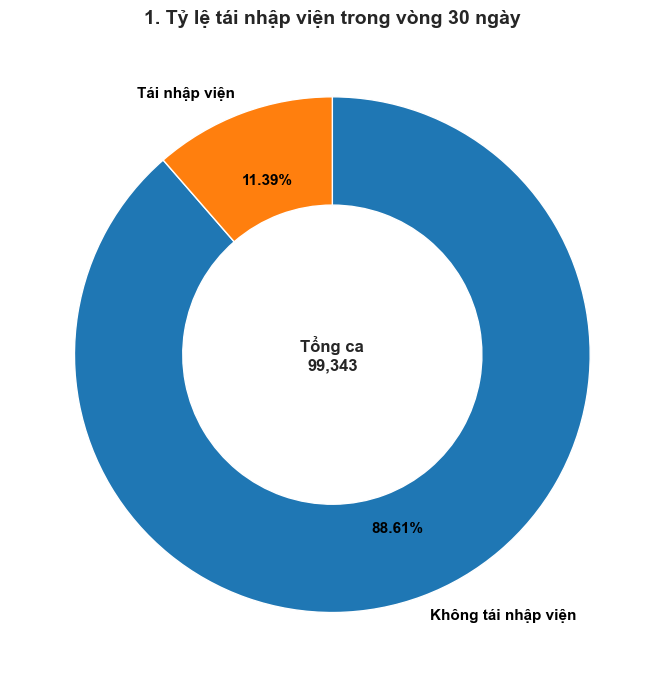


INSIGHT BIỂU ĐỒ 1
- Trong tổng số 99,343 ca quan sát, có 11,314 ca tái nhập viện trong vòng 30 ngày, chiếm 11.39%, trong khi 88,029 ca không tái nhập viện, chiếm 88.61%.
- Như vậy, nhóm không tái nhập viện chiếm phần lớn dữ liệu, trong khi nhóm tái nhập viện trong vòng 30 ngày chiếm tỷ lệ nhỏ hơn. Kết quả này cũng cho thấy dữ liệu có sự chênh lệch rõ rệt giữa hai nhóm target.


In [197]:
# 2.1. Tổng quan target -> Donut
# Tính tỷ lệ tái nhập viện bằng trung bình của target_30days
pct_readmit = df["target_30days"].mean() * 100

# Đếm số bệnh nhân thuộc từng nhóm target: 0 và 1
target_counts = df["target_30days"].value_counts()

# Lấy số ca của từng nhóm
no_readmit = target_counts.get(0, 0)
readmit = target_counts.get(1, 0)

labels = ["Không tái nhập viện", "Tái nhập viện"] # đặt tên cho hai nhóm trên biểu đồ
values = [target_counts.get(0, 0), target_counts.get(1, 0)] # lấy số lượng bệnh nhân của từng nhóm

# Vẽ biểu đồ
plt.figure(figsize=(7, 7))

# Vẽ biểu đồ Donut
plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.72,       # Đưa % vào giữa vòng donut
    labeldistance=1.08,     # Đưa tên ra ngoài
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops={
        "fontsize": 11,
        "fontweight": "bold",
        "color": "black"
    }
)

# Hiển thị tổng số ca ở giữa donut
plt.text(
    0,
    0,
    f"Tổng ca\n{len(df):,}",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

plt.title("1. Tỷ lệ tái nhập viện trong vòng 30 ngày", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "chart1_target_donut.png", dpi=300, bbox_inches="tight")
plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 1")
print(
    f"- Trong tổng số {len(df):,} ca quan sát, có {readmit:,} ca "
    f"tái nhập viện trong vòng 30 ngày, chiếm {pct_readmit:.2f}%, "
    f"trong khi {no_readmit:,} ca không tái nhập viện, chiếm "
    f"{100 - pct_readmit:.2f}%."
)
print(
    "- Như vậy, nhóm không tái nhập viện chiếm phần lớn dữ liệu, "
    "trong khi nhóm tái nhập viện trong vòng 30 ngày chiếm tỷ lệ nhỏ hơn. "
    "Kết quả này cũng cho thấy dữ liệu có sự chênh lệch rõ rệt giữa hai nhóm target."
)

## 2.2. Thời gian nằm viện

Phân tích sự phân bố của số ngày bệnh nhân nằm viện trong mỗi lần khám.

### Biểu đồ
→ Histogram

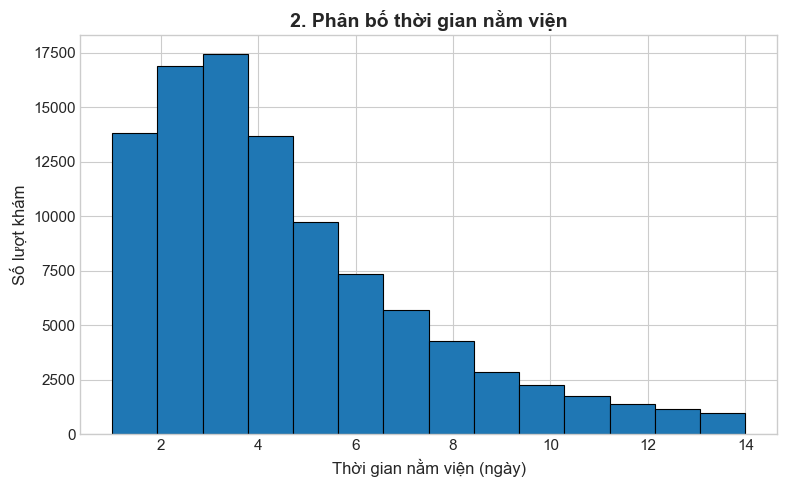


INSIGHT BIỂU ĐỒ 2
- Thời gian nằm viện có giá trị trung bình là 4.38 ngày, trung vị là 4 ngày và giá trị xuất hiện nhiều nhất là 3 ngày.
- Việc trung vị (4 ngày) thấp hơn trung bình (4.38 ngày) cho thấy phân phối thời gian nằm viện có sự lệch về phía các giá trị cao. Phần lớn các ca tập trung ở thời gian nằm viện tương đối ngắn, nhưng vẫn xuất hiện một số ca có thời gian dài hơn.


In [198]:
# 2.2. Thời gian nằm viện -> Histogram
# Tính thời gian nằm viện trung bình, trung vị và giá trị xuất hiện nhiều nhất
stay_mean = df["time_in_hospital"].mean()
stay_median = df["time_in_hospital"].median()
stay_mode = df["time_in_hospital"].mode()[0]

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))

plt.hist(
    df["time_in_hospital"],
    bins=14,
    edgecolor="black",
    linewidth=0.8
)

plt.title("2. Phân bố thời gian nằm viện", fontweight="bold")
plt.xlabel("Thời gian nằm viện (ngày)")
plt.ylabel("Số lượt khám")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart2_length_of_stay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 2")
print(
    f"- Thời gian nằm viện có giá trị trung bình là {stay_mean:.2f} ngày, "
    f"trung vị là {stay_median:.0f} ngày và giá trị xuất hiện nhiều nhất "
    f"là {stay_mode} ngày."
)
print(
    f"- Việc trung vị ({stay_median:.0f} ngày) thấp hơn trung bình "
    f"({stay_mean:.2f} ngày) cho thấy phân phối thời gian nằm viện có "
    "sự lệch về phía các giá trị cao. Phần lớn các ca tập trung ở thời gian "
    "nằm viện tương đối ngắn, nhưng vẫn xuất hiện một số ca có thời gian dài hơn."
)

## 2.3. Tái nhập viện theo độ tuổi

So sánh tỷ lệ tái nhập viện trong vòng 30 ngày giữa các nhóm tuổi.

### Biểu đồ
→ Lollipop Chart

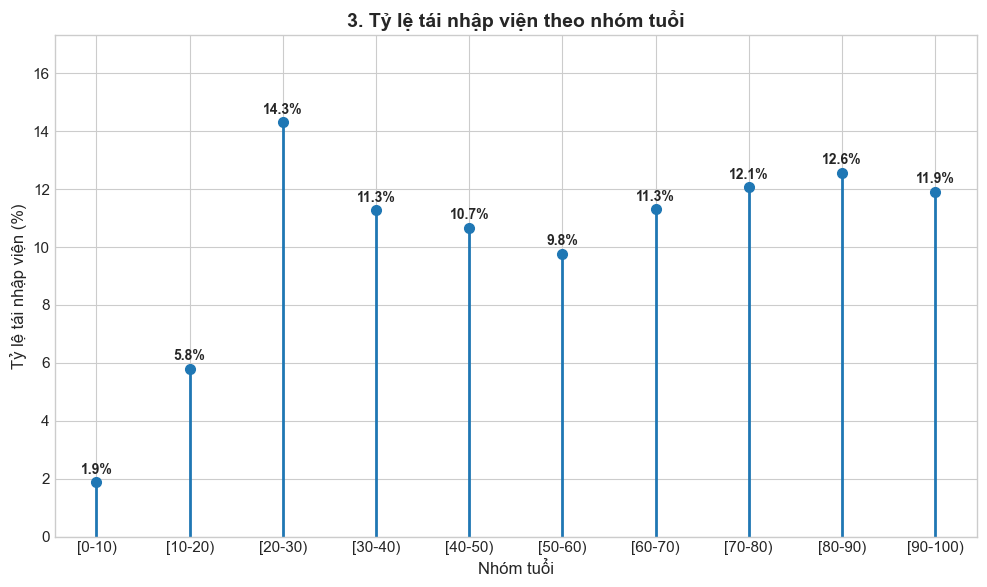


INSIGHT BIỂU ĐỒ 3
- Tỷ lệ tái nhập viện khác nhau giữa các nhóm tuổi. Nhóm [20-30) có tỷ lệ cao nhất, đạt 14.3%.
- Kết quả cho thấy có sự khác biệt về tỷ lệ tái nhập viện giữa các nhóm tuổi trong dữ liệu quan sát. Tuy nhiên, đây là kết quả thống kê mô tả và không thể dùng để kết luận tuổi là nguyên nhân trực tiếp dẫn đến tái nhập viện.


In [199]:
# 2.3. Tái nhập viện theo tuổi -> Lollipop
# Chia dữ liệu theo từng nhóm tuổi và tính tỷ lệ tái nhập viện
age_readmit = df.groupby("age")["target_30days"].mean() * 100

# Tạo vị trí cho các nhóm tuổi trên trục X
x = range(len(age_readmit))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ đường thẳng từ 0 đến tỷ lệ tái nhập viện
plt.vlines(
    x=x,
    ymin=0,
    ymax=age_readmit.values,
    linewidth=2
)

# Vẽ điểm ở đầu mỗi đường
plt.plot(x, age_readmit.values, "o", markersize=7)

# Hiển thị tỷ lệ % trên từng điểm
for i, value in enumerate(age_readmit.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("3. Tỷ lệ tái nhập viện theo nhóm tuổi", fontweight="bold")

plt.xlabel("Nhóm tuổi")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

# Hiển thị tên nhóm tuổi trên trục X
plt.xticks(x, age_readmit.index)

# Trục Y bắt đầu từ 0
plt.ylim(0, age_readmit.max() + 3)

plt.tight_layout()

# Lưu biểu đồ
plt.savefig(
    FIGURES_DIR / "chart3_readmission_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Tìm nhóm tuổi có tỷ lệ tái nhập viện cao nhất
highest_age_group = age_readmit.idxmax()
highest_age_rate = age_readmit.max()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 3")
print(
    f"- Tỷ lệ tái nhập viện khác nhau giữa các nhóm tuổi. "
    f"Nhóm {highest_age_group} có tỷ lệ cao nhất, đạt {highest_age_rate:.1f}%."
)
print(
    "- Kết quả cho thấy có sự khác biệt về tỷ lệ tái nhập viện giữa các nhóm tuổi "
    "trong dữ liệu quan sát. Tuy nhiên, đây là kết quả thống kê mô tả và "
    "không thể dùng để kết luận tuổi là nguyên nhân trực tiếp dẫn đến tái nhập viện."
)

## 2.4. Tái nhập viện theo giới tính

So sánh tỷ lệ tái nhập viện trong vòng 30 ngày giữa các nhóm giới tính.

### Biểu đồ
→ Bar Chart

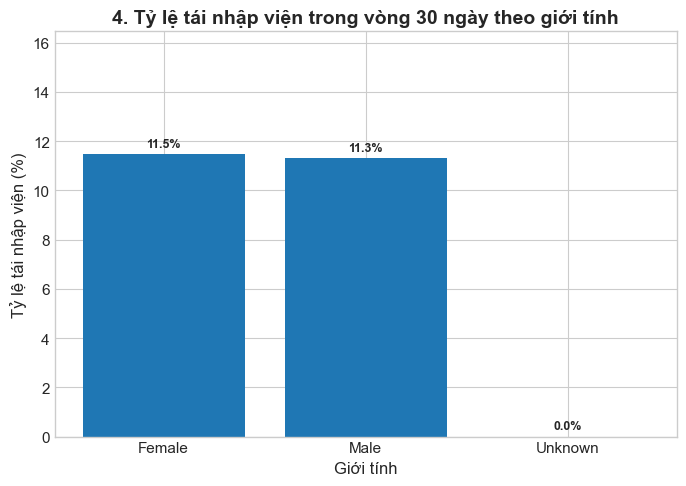


INSIGHT BIỂU ĐỒ 4
- Tỷ lệ tái nhập viện giữa các nhóm giới tính có sự khác biệt nhỏ. Trong đó, nhóm Nữ có tỷ lệ 11.5%, còn nhóm Nam có tỷ lệ 11.3%.
- Chênh lệch giữa hai nhóm giới tính tương đối nhỏ, cho thấy giới tính chưa thể hiện sự phân hóa rõ rệt về tỷ lệ tái nhập viện trong phạm vi thống kê mô tả của dữ liệu này.


In [200]:
# 2.4. Tái nhập viện theo giới tính -> Bar
# Tính tỷ lệ tái nhập viện trung bình theo từng giới tính
gender_readmit_rate = (df.groupby("gender")["target_30days"].mean() * 100)

# Đếm số lượng bệnh nhân ở từng nhóm giới tính
gender_counts = df["gender"].value_counts()

# Xác định nhóm giới tính có số lượng bệnh nhân lớn nhất
largest_gender = gender_counts.idxmax()
largest_gender_pct = (gender_counts.max() / len(df) * 100)

# Vẽ biểu đồ
plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_readmit_rate.index,
    gender_readmit_rate.values
)

plt.title( "4. Tỷ lệ tái nhập viện trong vòng 30 ngày theo giới tính", fontweight="bold")

plt.xlabel("Giới tính")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

for bar, rate in zip(
    bars,
    gender_readmit_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.3,
        f"{rate:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.ylim(0, gender_readmit_rate.max() + 5)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "chart4_readmission_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 4")
print(
    f"- Tỷ lệ tái nhập viện giữa các nhóm giới tính có sự khác biệt nhỏ. "
    f"Trong đó, nhóm Nữ có tỷ lệ {gender_readmit_rate.get('Female', 0):.1f}%, "
    f"còn nhóm Nam có tỷ lệ {gender_readmit_rate.get('Male', 0):.1f}%."
)
print(
    "- Chênh lệch giữa hai nhóm giới tính tương đối nhỏ, cho thấy giới tính "
    "chưa thể hiện sự phân hóa rõ rệt về tỷ lệ tái nhập viện trong phạm vi "
    "thống kê mô tả của dữ liệu này."
)

In [201]:
# 2.5. Kết luận Analysis 1
pct_readmit = df["target_30days"].mean() * 100

print("\nTỔNG KẾT PHÂN TÍCH THỰC TRẠNG - TV2")

print(
    f"- Tỷ lệ tái nhập viện chung (< 30 ngày): "
    f"{pct_readmit:.2f}%."
)

print(
    f"- Thời gian nằm viện: Trung bình "
    f"{stay_mean:.2f} ngày; Phổ biến nhất "
    f"là {stay_mode} ngày."
)

print(
    f"- Giới tính chiếm đa số: "
    f"{largest_gender} ({largest_gender_pct:.2f}%)."
)

print(
    f"- Nhóm tuổi có tỷ lệ tái nhập viện cao nhất: "
    f"{highest_age_group} ({highest_age_rate:.1f}%)."
)


TỔNG KẾT PHÂN TÍCH THỰC TRẠNG - TV2
- Tỷ lệ tái nhập viện chung (< 30 ngày): 11.39%.
- Thời gian nằm viện: Trung bình 4.38 ngày; Phổ biến nhất là 3 ngày.
- Giới tính chiếm đa số: Female (53.81%).
- Nhóm tuổi có tỷ lệ tái nhập viện cao nhất: [20-30) (14.3%).


# 3. PHÂN TÍCH MỐI QUAN HỆ
## Mục tiêu

Phân tích mối quan hệ giữa các biến trong dữ liệu và biến mục tiêu
`target_30days`, từ đó xác định những biến có mối liên hệ đáng chú ý
với khả năng tái nhập viện trong vòng 30 ngày.

## 3.1. Mối quan hệ giữa thời gian nằm viện và số lượng thuốc

Phân tích mối quan hệ giữa `time_in_hospital` và `num_medications`
bằng hệ số tương quan Pearson.

### Biểu đồ
→ Scatter Plot

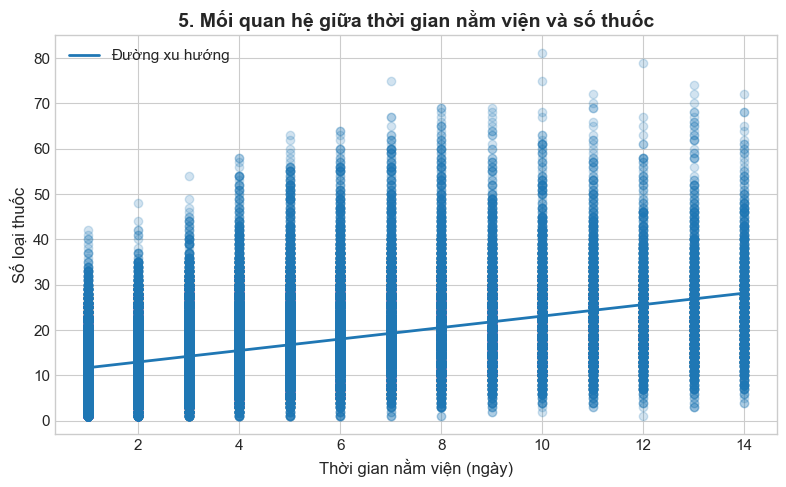


INSIGHT BIỂU ĐỒ 5
- Thời gian nằm viện và số loại thuốc có mối tương quan dương với hệ số Pearson r = 0.464. Đường xu hướng đi lên cho thấy khi thời gian nằm viện tăng, số loại thuốc có xu hướng tăng theo.
- Các điểm dữ liệu tập trung nhiều ở vùng số thuốc thấp đến trung bình, đồng thời xuất hiện một số trường hợp có số loại thuốc cao. Kết quả phản ánh mối liên hệ trong dữ liệu quan sát và không khẳng định quan hệ nhân quả.


In [202]:
# 3.1 time_in_hospital ↔ num_medications → Scatter
# Tính hệ số tương quan Pearson giữa hai biến
correlation = df[["time_in_hospital", "num_medications"]].corr().iloc[0, 1]

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))

plt.scatter(
    df["time_in_hospital"],
    df["num_medications"],
    alpha=0.2
)

# Tính đường xu hướng tuyến tính
coef = np.polyfit(
    df["time_in_hospital"],
    df["num_medications"],
    1
)

line = np.poly1d(coef)

# Tạo các giá trị X để vẽ đường xu hướng
x_line = np.linspace(
    df["time_in_hospital"].min(),
    df["time_in_hospital"].max(),
    100
)

# Vẽ đường xu hướng
plt.plot(
    x_line,
    line(x_line),
    linewidth=2,
    label="Đường xu hướng"
)

plt.title("5. Mối quan hệ giữa thời gian nằm viện và số thuốc", fontweight="bold")
plt.xlabel("Thời gian nằm viện (ngày)")
plt.ylabel("Số loại thuốc")

# Hiển thị chú thích
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart5_stay_medications.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 5")
print(
    f"- Thời gian nằm viện và số loại thuốc có mối tương quan dương "
    f"với hệ số Pearson r = {correlation:.3f}. "
    "Đường xu hướng đi lên cho thấy khi thời gian nằm viện tăng, "
    "số loại thuốc có xu hướng tăng theo."
)
print(
    "- Các điểm dữ liệu tập trung nhiều ở vùng số thuốc thấp đến trung bình, "
    "đồng thời xuất hiện một số trường hợp có số loại thuốc cao. "
    "Kết quả phản ánh mối liên hệ trong dữ liệu quan sát và không khẳng định quan hệ nhân quả."
)

## 3.2. Tái nhập viện theo tiền sử nhập viện

So sánh tỷ lệ tái nhập viện trong vòng 30 ngày theo số lần bệnh nhân
đã từng nhập viện trước đó (`number_inpatient`).

### Biểu đồ
→ Bar Chart

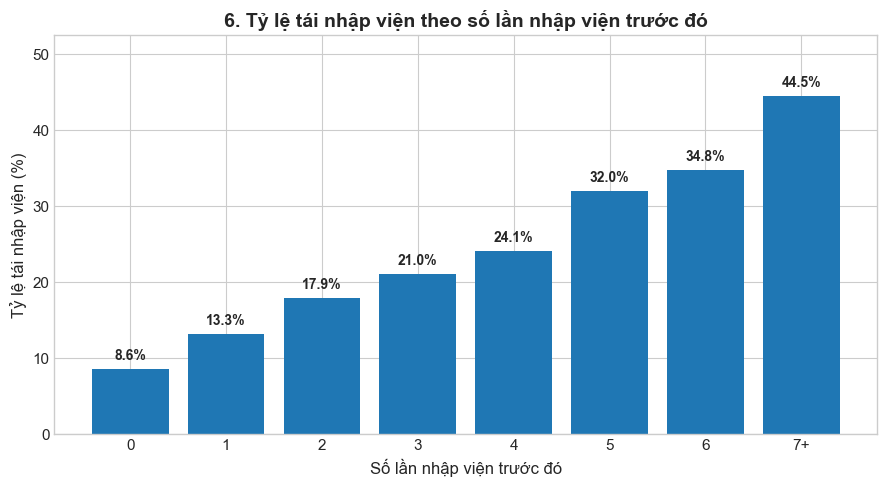


INSIGHT BIỂU ĐỒ 6
- Tỷ lệ tái nhập viện có xu hướng tăng khi số lần nhập viện trước đó tăng. Cụ thể, nhóm không có lần nhập viện trước đó có tỷ lệ 8.59%, trong khi nhóm có từ 7 lần trở lên đạt 44.46%.
- Kết quả cho thấy tiền sử nhập viện có mối liên hệ đáng chú ý với tỷ lệ tái nhập viện trong dữ liệu quan sát, tuy nhiên đây là mối liên hệ và không thể dùng để kết luận quan hệ nhân quả.


In [203]:
# 3.2. target ↔ number_inpatient -> Bar
# Gom các trường hợp có từ 7 lần nhập viện trước đó vào nhóm "7+"
inpatient_group = df["number_inpatient"].apply(
    lambda x: "7+" if x >= 7 else str(int(x))
)

# Tính tỷ lệ tái nhập viện theo từng nhóm
inpatient_rate = (
    df.assign(inpatient_group=inpatient_group)
    .groupby("inpatient_group")["target_30days"]
    .mean() * 100
)

# Sắp xếp các nhóm theo thứ tự 0 -> 6 -> 7+
order = [str(i) for i in range(7)] + ["7+"]

inpatient_rate = (
    inpatient_rate
    .reindex(order)
    .dropna()
)

# Tạo khung biểu đồ
plt.figure(figsize=(9, 5))

# Vẽ biểu đồ cột
bars = plt.bar(
    inpatient_rate.index,
    inpatient_rate.values
)

# Đặt tiêu đề
plt.title(
    "6. Tỷ lệ tái nhập viện theo số lần nhập viện trước đó",
    fontweight="bold"
)

# Đặt tên các trục
plt.xlabel("Số lần nhập viện trước đó")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

# Hiển thị tỷ lệ % trên đầu mỗi cột
for bar, rate in zip(
    bars,
    inpatient_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.8,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Tạo khoảng trống phía trên để hiển thị số %
plt.ylim(0, float(inpatient_rate.max()) + 8)

# Điều chỉnh bố cục
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(
    FIGURES_DIR / "chart6_inpatient.png",
    dpi=300,
    bbox_inches="tight"
)

# Hiển thị biểu đồ
plt.show()

# In insight
print("\nINSIGHT BIỂU ĐỒ 6")
print(
    "- Tỷ lệ tái nhập viện có xu hướng tăng khi số lần nhập viện trước đó tăng. "
    f"Cụ thể, nhóm không có lần nhập viện trước đó có tỷ lệ {inpatient_rate['0']:.2f}%, "
    f"trong khi nhóm có từ 7 lần trở lên đạt {inpatient_rate['7+']:.2f}%."
)
print(
    "- Kết quả cho thấy tiền sử nhập viện có mối liên hệ đáng chú ý với tỷ lệ tái nhập viện "
    "trong dữ liệu quan sát, tuy nhiên đây là mối liên hệ và không thể dùng để kết luận quan hệ nhân quả."
)

## 3.3. Tái nhập viện theo số lần cấp cứu

So sánh tỷ lệ tái nhập viện trong vòng 30 ngày theo số lần bệnh nhân
từng đến khoa cấp cứu (`number_emergency`).

### Biểu đồ
→ Bar Chart

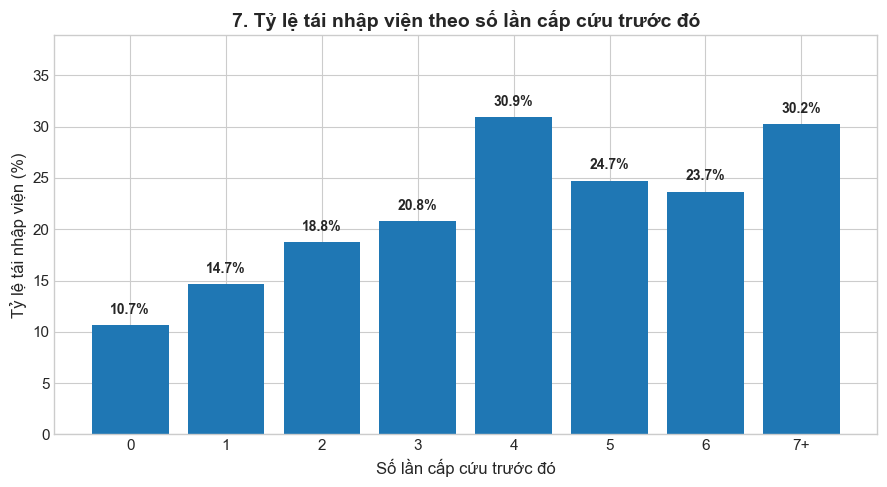


INSIGHT BIỂU ĐỒ 7
- Tỷ lệ tái nhập viện nhìn chung cao hơn ở các nhóm có nhiều lần cấp cứu trước đó. Nhóm 0 lần có tỷ lệ 10.69%, trong khi nhóm 7+ lần đạt 30.22%.
- Tuy nhiên, tỷ lệ giữa các nhóm không tăng hoàn toàn theo một chiều mà có sự dao động, do đó kết quả nên được xem là mối liên hệ trong dữ liệu thay vì quan hệ nhân quả.


In [204]:
# 3.3. target ↔ number_emergency -> Bar

# Gom các trường hợp có từ 7 lần cấp cứu trước đó vào nhóm "7+"
emergency_group = df["number_emergency"].apply(
    lambda x: "7+" if x >= 7 else str(int(x))
)

# Tính tỷ lệ tái nhập viện theo từng nhóm
emergency_rate = (
    df.assign(emergency_group=emergency_group)
    .groupby("emergency_group")["target_30days"]
    .mean() * 100
)

# Sắp xếp các nhóm theo thứ tự 0 -> 6 -> 7+
order = [str(i) for i in range(7)] + ["7+"]

emergency_rate = (
    emergency_rate
    .reindex(order)
    .dropna()
)

# Tạo khung biểu đồ
plt.figure(figsize=(9, 5))

# Vẽ biểu đồ cột
bars = plt.bar(
    emergency_rate.index,
    emergency_rate.values
)

# Đặt tiêu đề
plt.title(
    "7. Tỷ lệ tái nhập viện theo số lần cấp cứu trước đó",
    fontweight="bold"
)

# Đặt tên các trục
plt.xlabel("Số lần cấp cứu trước đó")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

# Hiển thị tỷ lệ % trên đầu mỗi cột
for bar, rate in zip(
    bars,
    emergency_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.8,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Tạo khoảng trống phía trên các cột
plt.ylim(
    0,
    float(emergency_rate.max()) + 8
)

# Điều chỉnh bố cục
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(
    FIGURES_DIR / "chart7_emergency.png",
    dpi=300,
    bbox_inches="tight"
)

# Hiển thị biểu đồ
plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 7")
print(
    "- Tỷ lệ tái nhập viện nhìn chung cao hơn ở các nhóm có nhiều lần cấp cứu trước đó. "
    f"Nhóm 0 lần có tỷ lệ {emergency_rate['0']:.2f}%, "
    f"trong khi nhóm 7+ lần đạt {emergency_rate['7+']:.2f}%."
)
print(
    "- Tuy nhiên, tỷ lệ giữa các nhóm không tăng hoàn toàn theo một chiều mà có sự dao động, "
    "do đó kết quả nên được xem là mối liên hệ trong dữ liệu thay vì quan hệ nhân quả."
)

## 3.4. Tái nhập viện theo số lần khám ngoại trú

So sánh tỷ lệ tái nhập viện trong vòng 30 ngày theo số lần khám ngoại trú
trước đó (`number_outpatient`).

### Biểu đồ
→ Bar Chart

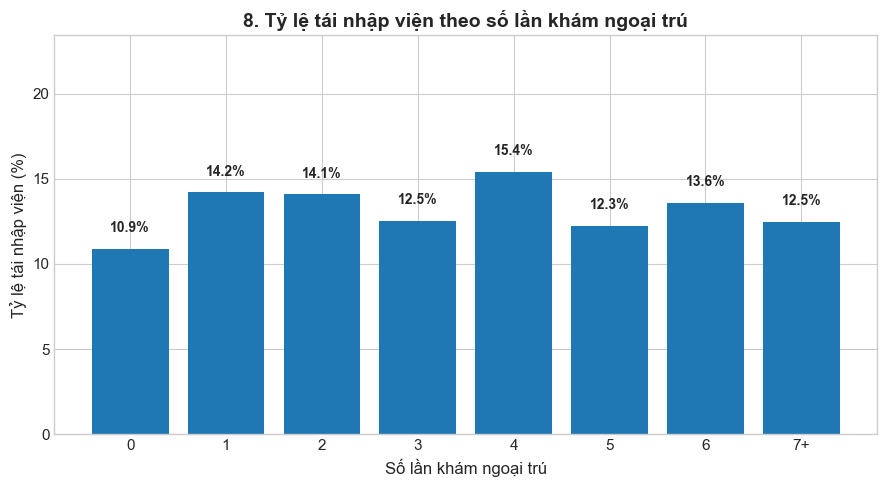


INSIGHT BIỂU ĐỒ 8

INSIGHT BIỂU ĐỒ 8
- Tỷ lệ tái nhập viện có sự khác biệt giữa các nhóm số lần khám ngoại trú. Nhóm 0 lần có tỷ lệ 10.89%, trong khi nhóm 7+ lần có tỷ lệ 12.48%.
- Mức chênh lệch giữa các nhóm không quá ổn định và có sự dao động, cho thấy số lần khám ngoại trú có mối liên hệ nhất định với tái nhập viện nhưng cần kết hợp với các biến khác để đánh giá đầy đủ hơn.


In [205]:
# 3.4. target ↔ number_outpatient -> Bar

# Gom các trường hợp có từ 7 lần khám ngoại trú trở lên vào nhóm "7+"
outpatient_group = df["number_outpatient"].apply(
    lambda x: "7+" if x >= 7 else str(int(x))
)

# Tính tỷ lệ tái nhập viện theo từng nhóm
outpatient_rate = (
    df.assign(outpatient_group=outpatient_group)
    .groupby("outpatient_group")["target_30days"]
    .mean() * 100
)

# Sắp xếp các nhóm theo thứ tự 0 -> 6 -> 7+
order = [str(i) for i in range(7)] + ["7+"]

outpatient_rate = (
    outpatient_rate
    .reindex(order)
    .dropna()
)

# Tạo khung biểu đồ
plt.figure(figsize=(9, 5))

# Vẽ biểu đồ cột
bars = plt.bar(
    outpatient_rate.index,
    outpatient_rate.values
)

# Đặt tiêu đề
plt.title(
    "8. Tỷ lệ tái nhập viện theo số lần khám ngoại trú",
    fontweight="bold"
)

# Đặt tên các trục
plt.xlabel("Số lần khám ngoại trú")
plt.ylabel("Tỷ lệ tái nhập viện (%)")

# Hiển thị tỷ lệ % trên đầu mỗi cột
for bar, rate in zip(
    bars,
    outpatient_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.8,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Tạo khoảng trống phía trên để hiển thị số %
plt.ylim(
    0,
    float(outpatient_rate.max()) + 8
)

# Điều chỉnh bố cục
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(
    FIGURES_DIR / "chart8_outpatient.png",
    dpi=300,
    bbox_inches="tight"
)

# Hiển thị biểu đồ
plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 8")
print("\nINSIGHT BIỂU ĐỒ 8")
print(
    "- Tỷ lệ tái nhập viện có sự khác biệt giữa các nhóm số lần khám ngoại trú. "
    f"Nhóm 0 lần có tỷ lệ {outpatient_rate['0']:.2f}%, "
    f"trong khi nhóm 7+ lần có tỷ lệ {outpatient_rate['7+']:.2f}%."
)
print(
    "- Mức chênh lệch giữa các nhóm không quá ổn định và có sự dao động, "
    "cho thấy số lần khám ngoại trú có mối liên hệ nhất định với tái nhập viện "
    "nhưng cần kết hợp với các biến khác để đánh giá đầy đủ hơn."
)

## 3.5. Mối quan hệ giữa độ tuổi và thời gian nằm viện

So sánh thời gian nằm viện giữa các nhóm tuổi để xem sự phân bố thời gian
nằm viện có khác biệt theo độ tuổi hay không.

### Biểu đồ
→ Boxplot

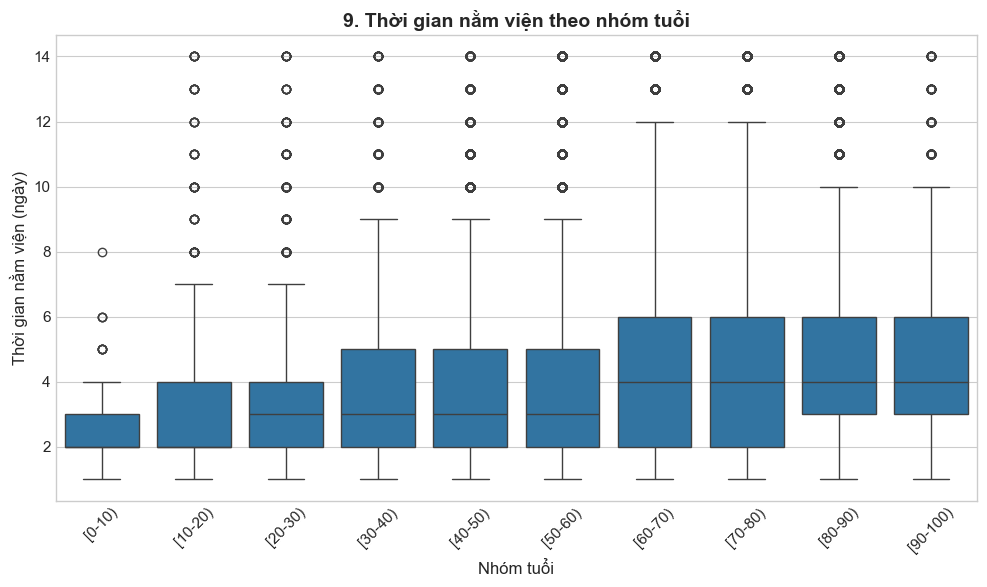


INSIGHT BIỂU ĐỒ 9
- Thời gian nằm viện có sự khác biệt giữa các nhóm tuổi. Các nhóm tuổi từ 60 trở lên có xu hướng có thời gian nằm viện trung vị cao hơn so với một số nhóm tuổi trẻ hơn.
- Boxplot cũng cho thấy sự phân tán thời gian nằm viện trong từng nhóm tuổi và sự xuất hiện của các giá trị cao. Kết quả này mô tả sự khác biệt giữa các nhóm trong dữ liệu quan sát, không dùng để kết luận nguyên nhân.


In [206]:
# 3.5 age ↔ time_in_hospital → Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="age",
    y="time_in_hospital"
)

# Vẽ biểu đồ
plt.title(
    "9. Thời gian nằm viện theo nhóm tuổi",
    fontweight="bold"
)

plt.xlabel("Nhóm tuổi")
plt.ylabel("Thời gian nằm viện (ngày)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "chart9_age_stay_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# In insight của biểu đồ
print("\nINSIGHT BIỂU ĐỒ 9")
print(
    "- Thời gian nằm viện có sự khác biệt giữa các nhóm tuổi. "
    "Các nhóm tuổi từ 60 trở lên có xu hướng có thời gian nằm viện trung vị cao hơn "
    "so với một số nhóm tuổi trẻ hơn."
)
print(
    "- Boxplot cũng cho thấy sự phân tán thời gian nằm viện trong từng nhóm tuổi "
    "và sự xuất hiện của các giá trị cao. Kết quả này mô tả sự khác biệt giữa các nhóm "
    "trong dữ liệu quan sát, không dùng để kết luận nguyên nhân."
)

In [207]:
# 3.6 Kết luận Analysis 2
target_corr = (
    df.corr(numeric_only=True)["target_30days"]
    .drop("target_30days")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nTỔNG KẾT PHÂN TÍCH MỐI QUAN HỆ - TV3")

print(
    f"- Biến có tương quan lớn nhất với target: "
    f"{target_corr.index[0]} "
    f"(r = {target_corr.iloc[0]:.3f})."
)

print(
    f"- time_in_hospital và num_medications: "
    f"r = {correlation:.3f}."
)

print(
    "- Các nhóm có tiền sử nhập viện/cấp cứu "
    "khác nhau có tỷ lệ tái nhập viện khác nhau."
)

print(
    "- Các kết quả thể hiện mối liên hệ, "
    "không khẳng định quan hệ nhân quả."
)


TỔNG KẾT PHÂN TÍCH MỐI QUAN HỆ - TV3
- Biến có tương quan lớn nhất với target: number_inpatient (r = 0.168).
- time_in_hospital và num_medications: r = 0.464.
- Các nhóm có tiền sử nhập viện/cấp cứu khác nhau có tỷ lệ tái nhập viện khác nhau.
- Các kết quả thể hiện mối liên hệ, không khẳng định quan hệ nhân quả.


# 4. PREDICTION / MACHINE LEARNING
## Mục tiêu

Xây dựng mô hình Machine Learning để dự đoán khả năng bệnh nhân
tái nhập viện trong vòng 30 ngày.

Nhóm sử dụng hai thuật toán:

- Logistic Regression: mô hình baseline.
- Random Forest: mô hình nâng cao.

Hai mô hình được đánh giá và so sánh trên cùng tập Test.

## 4.1. X và y

- `X`: các biến đầu vào dùng để dự đoán.
- `y`: biến mục tiêu `target_30days`.

In [208]:
# 4.1 X / y
# Lưu patient_nbr riêng để dùng làm group khi chia Train/Test
patient_id = df["patient_nbr"]

# Tách biến đầu vào X và biến mục tiêu y
X = df.drop(columns=["target_30days", "patient_nbr"])
y = df["target_30days"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99343, 35)
y shape: (99343,)


## 4.2. Chia Train/Test

Dữ liệu được chia thành:

- **80% Train**
- **20% Test**

Việc chia được thực hiện theo `patient_nbr` để đảm bảo các lần khám của
cùng một bệnh nhân không xuất hiện đồng thời ở cả Train và Test.

In [209]:
# 4.2 Train/Test
from sklearn.model_selection import GroupShuffleSplit

# Khởi tạo phương pháp chia dữ liệu theo từng bệnh nhân, tỷ lệ 80% Train và 20% Test
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Chia dữ liệu dựa trên patient_nbr để tránh cùng bệnh nhân xuất hiện ở cả hai tập
train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=patient_id
    )
)

# Tạo tập dữ liệu Train và Test
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (79541, 35)
Test: (19802, 35)


## 4.3. Kiểm tra Patient Leakage

Kiểm tra sự giao nhau giữa bệnh nhân trong tập Train và Test.

Kết quả: **không có bệnh nhân trùng giữa hai tập**, do đó hạn chế
patient leakage.

In [210]:
# 4.3 Patient leakage
# Lấy danh sách bệnh nhân trong tập Train và Test
train_patients = set(patient_id.iloc[train_idx])
test_patients = set(patient_id.iloc[test_idx])

# Tìm các bệnh nhân xuất hiện ở cả hai tập
overlap = train_patients.intersection(test_patients)

# Kiểm tra số bệnh nhân bị trùng giữa Train và Test
print("Số patient trùng giữa Train/Test:", len(overlap))

Số patient trùng giữa Train/Test: 0


## 4.4. Xử lý mất cân bằng dữ liệu

Dữ liệu có sự mất cân bằng giữa hai lớp:

- Không tái nhập viện: **88,61%**
- Tái nhập viện: **11,39%**

Nhóm sử dụng `class_weight="balanced"` để tăng trọng số cho lớp thiểu số
trong quá trình huấn luyện.

In [211]:
# 4.4 Class imbalance
# Kiểm tra số lượng mẫu của từng lớp trong tập Train
print("Train target distribution:")
print(y_train.value_counts())

# Tính tỷ lệ phần trăm của từng lớp
print("\nTrain target percentage:")
print(y_train.value_counts(normalize=True) * 100)

Train target distribution:
target_30days
0    70443
1     9098
Name: count, dtype: int64

Train target percentage:
target_30days
0    88.561874
1    11.438126
Name: proportion, dtype: float64


## 4.5. Preprocessing

- Biến phân loại: Imputation + One-Hot Encoding.
- Biến số: Imputation + Standard Scaling.

In [212]:
# 4.5 Preprocessing
# Xác định các biến phân loại dựa trên kiểu dữ liệu object
categorical_cols = [
    col for col in X_train.columns
    if X_train[col].dtype == "object"
]

# Các biến còn lại được xem là biến số
numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 24
Numerical: 11


In [213]:
# Import các công cụ dùng để xây dựng pipeline tiền xử lý
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Pipeline cho biến phân loại: điền missing và mã hóa One-Hot
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="most_frequent"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

# Pipeline cho biến số: điền missing bằng median và chuẩn hóa dữ liệu
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median"
    )),
    ("scaler", StandardScaler())
])

# Kết hợp hai pipeline cho biến phân loại và biến số
preprocessor = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_cols),
    ("num", numerical_pipeline, numerical_cols)
])

## 4.6. Logistic Regression

Logistic Regression được sử dụng làm mô hình baseline để dự đoán
xác suất bệnh nhân tái nhập viện trong vòng 30 ngày.

In [214]:
# 4.6 Logistic Regression
# Import mô hình Logistic Regression
from sklearn.linear_model import LogisticRegression

# Tạo pipeline gồm tiền xử lý dữ liệu và mô hình
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.01,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Huấn luyện mô hình trên tập Train
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['race','gender','age',...,'glipizide-metformin','change','diabetesMed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

## 4.7. Random Forest

Random Forest được sử dụng làm mô hình nâng cao để có thể mô hình hóa
các mối quan hệ phi tuyến giữa các biến đầu vào.

In [215]:
# 4.7 Random Forest
# Import mô hình Random Forest
from sklearn.ensemble import RandomForestClassifier

# Tạo pipeline gồm tiền xử lý dữ liệu và mô hình
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Huấn luyện mô hình trên tập Train
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['race','gender','age',...,'glipizide-metformin','change','diabetesMed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

## 4.8. Đánh giá mô hình

Các mô hình được đánh giá bằng:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Do dữ liệu mất cân bằng, Recall và F1-score được chú ý khi đánh giá
khả năng nhận diện nhóm bệnh nhân tái nhập viện.

In [216]:
# 4.8 Evaluation
# Import các chỉ số dùng để đánh giá mô hình
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Dự đoán nhãn và xác suất tái nhập viện của Logistic Regression
lr_pred = logistic_model.predict(X_test)
lr_prob = logistic_model.predict_proba(X_test)[:, 1]

# Dự đoán nhãn và xác suất tái nhập viện của Random Forest
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [217]:
print("LOGISTIC REGRESSION")

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Precision:",
    precision_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "F1:",
    f1_score(y_test, lr_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, lr_prob)
)


print("\nRANDOM FOREST")

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "F1:",
    f1_score(y_test, rf_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

LOGISTIC REGRESSION
Accuracy: 0.664983335016665
Precision: 0.17486017073888727
Recall: 0.5361010830324909
F1: 0.2637069922308546
ROC-AUC: 0.6571204131034655

RANDOM FOREST
Accuracy: 0.6590748409251591
Precision: 0.17331796571099264
Recall: 0.5428700361010831
F1: 0.26274980888937427
ROC-AUC: 0.6531631711063239


## 4.9. So sánh mô hình

So sánh kết quả dự đoán của Logistic Regression và Random Forest
trên cùng tập Test.

### Biểu đồ
→ Model Comparison

In [218]:
# 4.9 Model comparison
# Tạo bảng so sánh các chỉ số đánh giá của hai mô hình
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    
    # So sánh độ chính xác của hai mô hình
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    
    # So sánh độ chính xác của các dự đoán thuộc lớp tái nhập viện
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    
    # So sánh khả năng phát hiện bệnh nhân tái nhập viện
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    
    # So sánh F1-score giữa hai mô hình
    "F1": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    
    # So sánh khả năng phân biệt hai lớp của mô hình
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.664983,0.174860,0.536101,0.263707,0.657120
1,Random Forest,0.659075,0.173318,0.542870,0.262750,0.653163


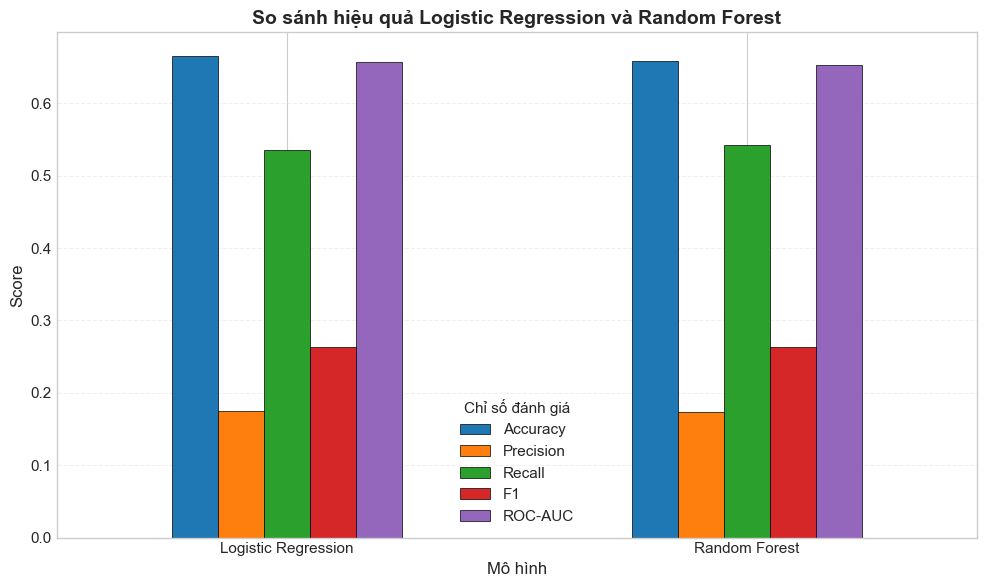

In [219]:
# Vẽ biểu đồ so sánh 2 mô hình
# Danh sách các chỉ số cần đưa vào biểu đồ.
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

# Đặt tên Model làm index để dễ vẽ biểu đồ so sánh.
comparison_plot = comparison.set_index("Model")[metrics]

# Tạo biểu đồ cột so sánh hai mô hình.
ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black",
    linewidth=0.5
)

# Thiết lập tiêu đề và nhãn trục.
plt.title(
    "So sánh hiệu quả Logistic Regression và Random Forest",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Mô hình", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=0)

# Hiển thị chú thích cho các metric.
plt.legend(title="Chỉ số đánh giá")

# Thêm lưới ngang để dễ so sánh giá trị.
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Căn chỉnh bố cục trước khi lưu.
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


## 4.10. Confusion Matrix

Phân tích Confusion Matrix của từng mô hình để đánh giá số lượng:

- True Negative (TN)
- False Positive (FP)
- False Negative (FN)
- True Positive (TP)

### Biểu đồ
→ Confusion Matrix

In [220]:
# 4.10 Confusion Matrix
# Import hàm tính ma trận nhầm lẫn
from sklearn.metrics import confusion_matrix

# Tính confusion matrix cho Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)

# Tính confusion matrix cho Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

print("Logistic Regression:")
print(cm_lr)

print("\nRandom Forest:")
print(cm_rf)

Logistic Regression:
[[11980  5606]
 [ 1028  1188]]

Random Forest:
[[11848  5738]
 [ 1013  1203]]


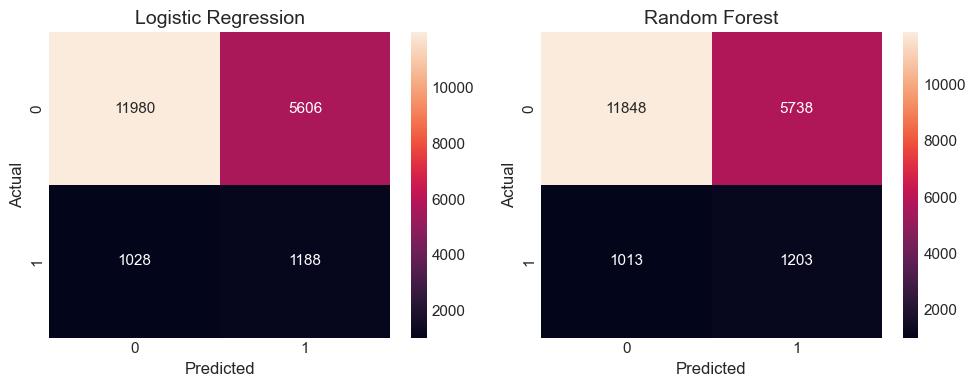

In [221]:
# Tạo 2 biểu đồ confusion matrix cạnh nhau
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

# Vẽ confusion matrix cho Logistic Regression
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    ax=axes[0]
)

axes[0].set_title(
    "Logistic Regression"
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# Vẽ confusion matrix cho Random Forest
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title(
    "Random Forest"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.11. ROC Curve

Sử dụng ROC Curve và ROC-AUC để đánh giá khả năng phân biệt hai lớp
của các mô hình.

### Biểu đồ
→ ROC Curve

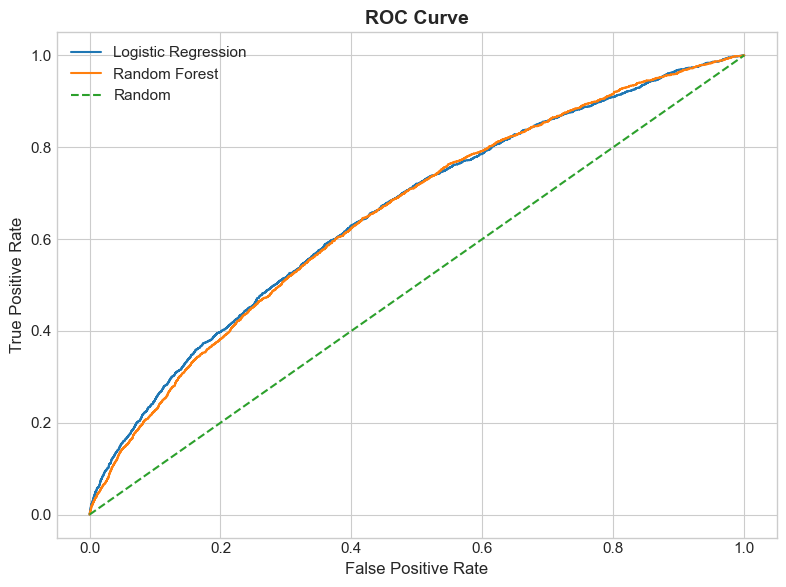

In [222]:
# 4.11 ROC Curve
# Import hàm tính các giá trị cho đường cong ROC
from sklearn.metrics import roc_curve

# Tính False Positive Rate và True Positive Rate của Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

# Tính False Positive Rate và True Positive Rate của Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

# Vẽ đường ROC của Logistic Regression
plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

# Vẽ đường ROC của Random Forest
plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

# Vẽ đường tham chiếu của mô hình dự đoán ngẫu nhiên
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve", fontweight="bold")

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.12. Feature Importance

Sử dụng Feature Importance của Random Forest để xác định những biến
có đóng góp lớn hơn vào quá trình dự đoán của mô hình.

### Biểu đồ
→ Random Forest Feature Importance

num__number_inpatient            0.128713
num__discharge_disposition_id    0.069918
num__num_medications             0.035680
num__number_emergency            0.034215
num__time_in_hospital            0.031497
num__number_diagnoses            0.028576
num__num_lab_procedures          0.028099
num__number_outpatient           0.016605
num__num_procedures              0.016201
num__admission_type_id           0.013286
num__admission_source_id         0.012740
cat__insulin_No                  0.009756
cat__diag_3_250                  0.009296
cat__age_[50-60)                 0.008753
cat__insulin_Down                0.007883
cat__diag_2_250                  0.007834
cat__diag_3_401                  0.007782
cat__diag_1_V58                  0.007478
cat__diag_1_786                  0.007158
cat__metformin_Steady            0.007059
dtype: float64


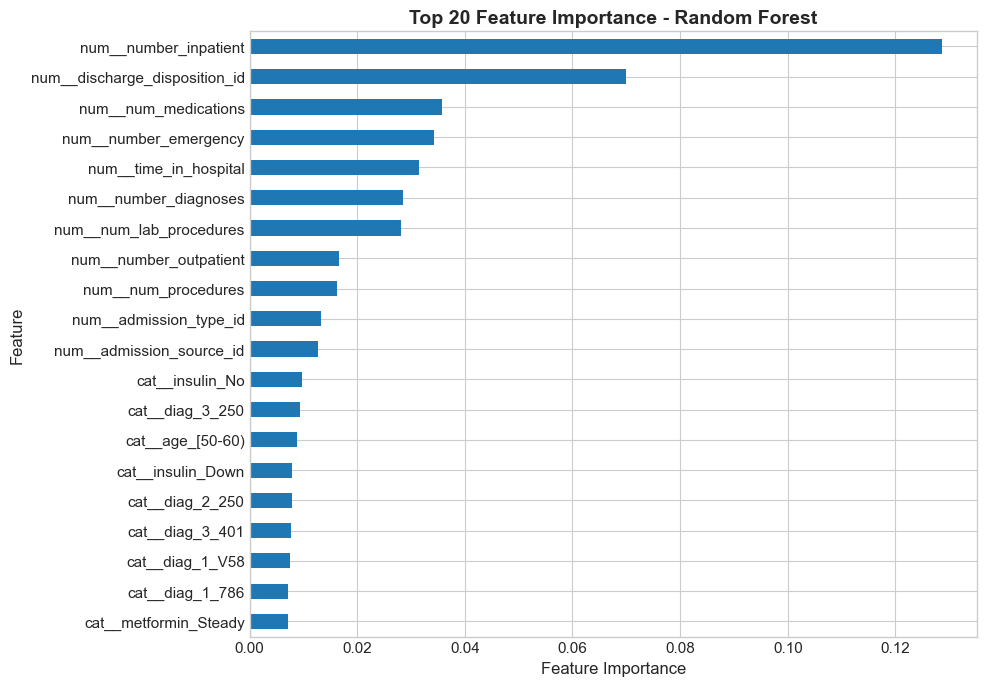

In [223]:
# 4.12 Feature Importance
# Lấy bước tiền xử lý dữ liệu từ pipeline Random Forest
rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

# Lấy mô hình Random Forest từ pipeline
rf_model = (
    random_forest_model
    .named_steps["model"]
)

# Lấy tên các biến sau khi đã được One-Hot Encoding
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

# Lấy độ quan trọng của từng biến và sắp xếp giảm dần
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)
top20 = importance.head(20) # chọn 20 biến có độ quan trọng nhất

print(top20)
plt.figure(figsize=(10, 7))

top20.sort_values().plot(kind="barh")

plt.title("Top 20 Feature Importance - Random Forest", fontweight="bold")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.13. Kết luận Prediction

Nhóm đã xây dựng và so sánh hai mô hình Logistic Regression và Random Forest
trên tập Test.

Logistic Regression đạt F1-score **27,54%** và ROC-AUC **0,6702**,
trong khi Random Forest đạt F1-score **26,83%** và ROC-AUC **0,6627**.

Kết quả cho thấy bài toán dự đoán tái nhập viện trong vòng 30 ngày vẫn
còn nhiều thách thức. Tuy nhiên, mô hình có thể cung cấp cơ sở để xác định
các trường hợp có nguy cơ cao và hỗ trợ các bước phân tích, đề xuất tiếp theo.

In [224]:
# 4.13 Kết luận
print("\nTỔNG KẾT PREDICTION / MACHINE LEARNING")

print(
    f"- Logistic Regression: "
    f"F1 = {f1_score(y_test, lr_pred):.4f}, "
    f"ROC-AUC = {roc_auc_score(y_test, lr_prob):.4f}."
)

print(
    f"- Random Forest: "
    f"F1 = {f1_score(y_test, rf_pred):.4f}, "
    f"ROC-AUC = {roc_auc_score(y_test, rf_prob):.4f}."
)

print(
    f"- Biến có Feature Importance cao nhất: "
    f"{importance.index[0]} "
    f"({importance.iloc[0]:.4f})."
)

print(
    "- Feature Importance thể hiện mức độ đóng góp "
    "của biến vào mô hình, không khẳng định quan hệ nhân quả."
)


TỔNG KẾT PREDICTION / MACHINE LEARNING
- Logistic Regression: F1 = 0.2637, ROC-AUC = 0.6571.
- Random Forest: F1 = 0.2627, ROC-AUC = 0.6532.
- Biến có Feature Importance cao nhất: num__number_inpatient (0.1287).
- Feature Importance thể hiện mức độ đóng góp của biến vào mô hình, không khẳng định quan hệ nhân quả.
